In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

use_cuda = True 

#device = torch.device("cuda") if use_cuda and torch.cuda.is_available() else torch.device("cpu")
device = torch.device("cuda")
print(f"Using device: {device}")

Using device: cuda


In [57]:
##define dummy data set for testing purposes- chatgpt
import math
def make_lidar_like_2d_dataset(
    n_background: int = 8000,
    n_noise: int = 1000,
    n_objects: int = 100,
    points_per_object: int = 80,
    r_min: float = 3.0,
    r_max: float = 60.0,
    device: str = "cpu",
    seed: int = 2,
):
    """
    Returns:
        points: (N,2) float32 tensor
        gt_obj_id: (N,) long tensor (-1 for background/noise, 0..n_objects-1 for objects)
    """
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    # ---------- Objects (clusters) ----------
    obj_centers_r = torch.empty(n_objects, device=device).uniform_(8.0, 55.0, generator=g)
    obj_centers_theta = torch.empty(n_objects, device=device).uniform_(-math.pi, math.pi, generator=g)

    obj_cx = obj_centers_r * torch.cos(obj_centers_theta)
    obj_cy = obj_centers_r * torch.sin(obj_centers_theta)
    centers = torch.stack([obj_cx, obj_cy], dim=1)  # (n_objects,2)

    # Each object has anisotropic spread that grows mildly with range (harder far away)
    # sigma ~ base + slope * r
    base_sigma = 0.08
    slope_sigma = 0.004
    sigmas = base_sigma + slope_sigma * obj_centers_r  # (n_objects,)

    obj_points = []
    obj_labels = []
    for c in range(n_objects):
        # Sample gaussian in local frame, with anisotropy
        n = points_per_object
        sx = sigmas[c] * 1.8
        sy = sigmas[c] * 0.9
        local = torch.randn((n, 2), device=device, generator=g)
        local[:, 0] *= sx
        local[:, 1] *= sy

        # Random rotate the ellipse
        ang = torch.empty((), device=device).uniform_(0, 2*math.pi, generator=g)
        R = torch.tensor([[torch.cos(ang), -torch.sin(ang)],
                          [torch.sin(ang),  torch.cos(ang)]], device=device)

        pts = local @ R.T + centers[c]
        obj_points.append(pts)
        obj_labels.append(torch.full((n,), c, device=device, dtype=torch.long))

    obj_points = torch.cat(obj_points, dim=0)
    obj_labels = torch.cat(obj_labels, dim=0)

    # ---------- Background “rings” (LiDAR-ish) ----------
    # Create many rays (angles) and sample ranges -> yields density ~ 1/r in xy
    # then add small noise.
    angles = torch.empty(n_background, device=device).uniform_(-math.pi, math.pi, generator=g)
    # bias toward mid/far ranges to simulate typical scan coverage
    u = torch.empty(n_background, device=device).uniform_(0, 1, generator=g)
    ranges = r_min + (r_max - r_min) * (u ** 0.6)

    bg_x = ranges * torch.cos(angles)
    bg_y = ranges * torch.sin(angles)

    # Add small radial/tangential jitter (in meters)
    bg = torch.stack([bg_x, bg_y], dim=1)
    bg += 0.03 * torch.randn(bg.shape, device=bg.device, generator=g)

    bg_labels = torch.full((n_background,), -1, device=device, dtype=torch.long)

    # ---------- Uniform noise ----------
    noise = torch.empty((n_noise, 2), device=device).uniform_(-r_max, r_max, generator=g)
    noise_labels = torch.full((n_noise,), -1, device=device, dtype=torch.long)

    points = torch.cat([obj_points, bg, noise], dim=0).to(torch.float32)
    gt = torch.cat([obj_labels, bg_labels, noise_labels], dim=0)

    return points, gt

# Example
points_cpu, gt = make_lidar_like_2d_dataset(device=device)
print(points_cpu.shape, gt.shape)


torch.Size([17000, 2]) torch.Size([17000])


In [58]:
## reason this is all being created. Need adaptive epsilon and min samples to accomdate relative radial resolution of the lidar sensor
points = points_cpu.to(device)
distances = torch.norm(points, p=2, dim=1)

#coefficients (tunable on real data)
a = 0.015
b = 0.15
min_samples_min = 9
mins_samples_max = 200
K = 1200
epsilons = a*distances + b

min_samples = torch.ceil(K / (distances ** 2)).to(torch.int64) 
min_samples = torch.maximum(min_samples, torch.tensor(min_samples_min, device=device))
min_samples = torch.minimum(min_samples, torch.tensor(mins_samples_max, device=device))


In [59]:
def grid_coords(points: torch.Tensor, cell: float):
    # points: (N, 2) float tensor
    # returns cx, cy: (N,) long tensors (integer cell coordinates)
    cx = torch.floor(points[:, 0] / cell).long()
    cy = torch.floor(points[:, 1] / cell).long()
    return cx, cy

In [60]:
from typing import Tuple

def build_edges_grid_adaptive_eps_oom_safe(
    points: torch.Tensor,
    eps_i: torch.Tensor,
    cell_quantile: float = 0.90,
    block: int = 2048,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Directed edges i->j if ||xi-xj|| <= eps_i[i], using:
      - cell size = quantile(eps_i)
      - offsets expanded to cover eps_max
      - blocked pairwise distance to avoid CUDA OOM
    """
    device = points.device
    N = points.shape[0]

    eps_max = eps_i.max().item()
    cell = torch.quantile(eps_i.detach().cpu(), cell_quantile).item()
    cell = max(cell, 0.2)  # clamp: prevents tiny cells from exploding dict overhead

    # how many cells away must we check to cover eps_max?
    R = max(1, int(math.ceil(eps_max / cell)))
    offsets = [(dx, dy) for dx in range(-R, R+1) for dy in range(-R, R+1)]

    # cell coords
    cx = torch.floor(points[:, 0] / cell).long()
    cy = torch.floor(points[:, 1] / cell).long()

    # grid dict on CPU (keys are Python ints); store indices as Python lists
    grid = {}
    # NOTE: moving cx/cy to cpu for dict ops avoids GPU->CPU sync per element
    cx_cpu = cx.detach().cpu().tolist()
    cy_cpu = cy.detach().cpu().tolist()
    for i in range(N):
        key = (cx_cpu[i], cy_cpu[i])
        grid.setdefault(key, []).append(i)

    src_all, dst_all = [], []

    for (gx, gy), idxs in grid.items():
        I = torch.tensor(idxs, device=device, dtype=torch.long)   # (a,)
        Pi = points[I]                                           # (a,2)
        eps2_i = (eps_i[I] ** 2)[:, None]                         # (a,1)

        for dx, dy in offsets:
            nkey = (gx + dx, gy + dy)
            jdxs = grid.get(nkey, None)
            if jdxs is None:
                continue

            J = torch.tensor(jdxs, device=device, dtype=torch.long)   # (b,)
            Pj = points[J]                                           # (b,2)

            # blocked compare over J
            b = Pj.shape[0]
            for start in range(0, b, block):
                end = min(start + block, b)
                Pjb = Pj[start:end]     # (bb,2)
                Jb  = J[start:end]      # (bb,)

                diff = Pi[:, None, :] - Pjb[None, :, :]    # (a,bb,2)
                dist2 = (diff * diff).sum(dim=2)           # (a,bb)
                mask = dist2 <= eps2_i                      # (a,bb)

                ii, jj = torch.where(mask)
                if ii.numel() > 0:
                    src_all.append(I[ii])
                    dst_all.append(Jb[jj])

    if len(src_all) == 0:
        return (torch.empty(0, dtype=torch.long, device=device),
                torch.empty(0, dtype=torch.long, device=device))

    src = torch.cat(src_all, dim=0)
    dst = torch.cat(dst_all, dim=0)

    keep = src != dst
    return src[keep], dst[keep]

src, dst = build_edges_grid_adaptive_eps_oom_safe(points,epsilons)

In [62]:
def dbscan_from_edges(N, src, dst, min_samples, max_iters=50):
    device = src.device

    # 1) neighbour counts
    counts = torch.bincount(src, minlength=N)

    # 2) core points
    core = counts >= min_samples

    # 3) keep only core-core neighbour relations (for forming core clusters)
    mask_cc = core[src] & core[dst]
    cc_src = src[mask_cc]
    cc_dst = dst[mask_cc]

    # 4) label spreading among core points
    labels = torch.full((N,), -1, device=device, dtype=torch.long)
    labels[core] = torch.arange(N, device=device, dtype=torch.long)[core]

    for _ in range(max_iters):
        old = labels
        cand = old[cc_src]
        new = old.clone()
        new.scatter_reduce_(0, cc_dst, cand, reduce="amin", include_self=True)
        labels = new
        if torch.equal(labels, old):
            break

    # 5) compress root labels into 0..K-1 cluster IDs (cores only)
    cluster = torch.full((N,), -1, device=device, dtype=torch.long)
    roots = labels[core]
    if roots.numel() > 0:
        unique_roots, inv = torch.unique(roots, sorted=True, return_inverse=True)
        cluster[core] = inv

    # 6) attach border points (non-core points that point to a core neighbour)
    mask_bc = (~core[src]) & core[dst]
    bc_src = src[mask_bc]
    bc_dst = dst[mask_bc]
    if bc_src.numel() > 0:
        cand_clusters = cluster[bc_dst]
        cluster2 = cluster.clone()
        cluster2.scatter_reduce_(0, bc_src, cand_clusters, reduce="amin", include_self=True)
        cluster = cluster2

    return cluster, core, counts

cluster,core,counts = dbscan_from_edges(points.size(dim=0), src, dst, min_samples, max_iters=500)

In [63]:
#testing purposes - print out clusters
points_cpu = points.detach().cpu()
cluster_cpu = cluster.detach().cpu()

valid = cluster_cpu >= 0

cluster_ids = torch.unique(cluster_cpu[valid])
num_clusters = cluster_ids.numel()

print("Num clusters:", num_clusters)
print("Num noise:", (cluster_cpu == -1).sum().item())

# Sizes: bincount works nicely because cluster ids are 0..K-1 in our pipeline
# If you’re not sure they’re contiguous, we’ll compute sizes by unique counts:
u, counts = torch.unique(cluster_cpu[valid], return_counts=True)
# Sort by cluster id
order = torch.argsort(u)
u = u[order]
counts = counts[order]

print("\nCluster sizes (cluster_id -> size):")
for cid, sz in zip(u.tolist(), counts.tolist()):
    print(f"  {cid+1:>3} -> {sz}")


K = int(cluster_ids.max().item()) + 1  # assumes cluster ids start at 0
pts = points_cpu  # (N,2)

# Sum coordinates per cluster
sums = torch.zeros((K, 2), dtype=pts.dtype)
sums.index_add_(0, cluster_cpu[valid], pts[valid])

# Counts per cluster (same ordering as sums)
cnts = torch.zeros((K,), dtype=torch.long)
cnts.index_add_(0, cluster_cpu[valid], torch.ones((valid.sum(),), dtype=torch.long))

# Centroids (avoid divide by zero)
centroids = sums / cnts.clamp(min=1).unsqueeze(1)  # (K,2)

print("\nCluster centroids (cluster_id -> (mean_x, mean_y)):")
for cid in range(K):
    if cnts[cid].item() == 0:
        continue
    mx, my = centroids[cid].tolist()
    print(f"  {cid+1:>3} -> ({mx:.3f}, {my:.3f})  size={cnts[cid].item()}")



Num clusters: 97
Num noise: 8836

Cluster sizes (cluster_id -> size):
    1 -> 80
    2 -> 84
    3 -> 79
    4 -> 80
    5 -> 82
    6 -> 82
    7 -> 76
    8 -> 86
    9 -> 86
   10 -> 82
   11 -> 83
   12 -> 79
   13 -> 82
   14 -> 75
   15 -> 84
   16 -> 85
   17 -> 161
   18 -> 79
   19 -> 79
   20 -> 83
   21 -> 81
   22 -> 84
   23 -> 89
   24 -> 79
   25 -> 165
   26 -> 78
   27 -> 86
   28 -> 80
   29 -> 86
   30 -> 87
   31 -> 75
   32 -> 80
   33 -> 82
   34 -> 79
   35 -> 83
   36 -> 83
   37 -> 83
   38 -> 84
   39 -> 80
   40 -> 82
   41 -> 83
   42 -> 81
   43 -> 80
   44 -> 82
   45 -> 86
   46 -> 84
   47 -> 83
   48 -> 83
   49 -> 78
   50 -> 79
   51 -> 81
   52 -> 85
   53 -> 77
   54 -> 84
   55 -> 78
   56 -> 87
   57 -> 165
   58 -> 80
   59 -> 77
   60 -> 81
   61 -> 82
   62 -> 79
   63 -> 79
   64 -> 80
   65 -> 89
   66 -> 81
   67 -> 79
   68 -> 80
   69 -> 81
   70 -> 86
   71 -> 85
   72 -> 70
   73 -> 80
   74 -> 82
   75 -> 79
   76 -> 79
   77 -> 89
   

Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.in

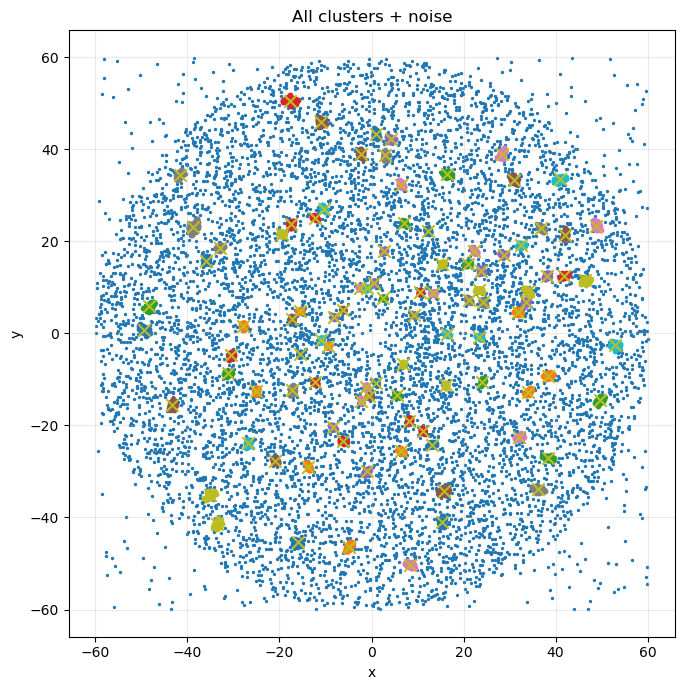

AssertionError: Expected 4 clusters, got 97

In [ ]:
from matplotlib.patches import Rectangle

pts = points_cpu.numpy()
clu = cluster_cpu.numpy()

cluster_ids = sorted([cid for cid in np.unique(clu) if cid >= 0])
print("Clusters:", cluster_ids, "Num noise:", int((clu == -1).sum()))

fig, ax = plt.subplots(figsize=(8, 7))

# Noise
m_noise = (clu == -1)
ax.scatter(pts[m_noise, 0], pts[m_noise, 1], marker='.', s=8, label="noise")

# Clusters
for cid in cluster_ids:
    m = (clu == cid)
    ax.scatter(pts[m, 0], pts[m, 1], s=10, label=f"cluster {cid}")

# Optional: centroids if you already computed them
if "centroids" in globals():
    cent = centroids.detach().cpu().numpy()
    # only plot centroids for clusters that exist
    ax.scatter(cent[cluster_ids, 0], cent[cluster_ids, 1], marker='x', s=80, label="centroids")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("All clusters + noise")
ax.set_aspect("equal", adjustable="box")
ax.legend(ncols=2, fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


"""
pts = points_cpu.numpy()
clu = cluster_cpu.numpy()

cluster_ids = sorted([cid for cid in np.unique(clu) if cid >= 0])
assert len(cluster_ids) == 4, f"Expected 4 clusters, got {len(cluster_ids)}"

padding_frac = 0.15  # 15% margin around cluster bbox

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for ax, cid in zip(axes, cluster_ids):
    m = (clu == cid)
    P = pts[m]  # (n_c,2)

    xmin, ymin = P.min(axis=0)
    xmax, ymax = P.max(axis=0)

    w = xmax - xmin
    h = ymax - ymin
    pad_x = padding_frac * (w if w > 0 else 1.0)
    pad_y = padding_frac * (h if h > 0 else 1.0)

    # (optional) show local noise around the cluster window
    xlo, xhi = xmin - pad_x, xmax + pad_x
    ylo, yhi = ymin - pad_y, ymax + pad_y
    mn = (clu == -1) & (pts[:,0] >= xlo) & (pts[:,0] <= xhi) & (pts[:,1] >= ylo) & (pts[:,1] <= yhi)
    ax.scatter(pts[mn, 0], pts[mn, 1], marker='.', s=10, alpha=0.25, label="noise")

    # cluster points
    ax.scatter(P[:, 0], P[:, 1], s=14, label=f"cluster {cid}")

    # bbox rectangle (boundary)
    rect = Rectangle((xmin, ymin), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)

    # zoom to bbox (+ padding)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)

    ax.set_title(f"Cluster {cid} (n={P.shape[0]})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle("Zoomed-in clusters (with bounding boxes)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


"""